# RTU 11 - Open-FDD Standalone Notebook

This notebook uses a **shared helper module** so the workflow stays identical across datasets. Only the config block below changes.

> Run the next cell to `pip install open-fdd --upgrade` and print the PyPI version. Column maps can use the default **`BrickTtlColumnMapResolver`** or a **`ManifestColumnMapResolver`** (see `examples/column_map_resolver_workshop/`).

Assumptions:
- `RTU11.csv` is in the same directory as this notebook
- `openfdd_notebook_helpers.py` is in the same directory as this notebook
- reusable YAML rule files live in `rules/` beside the notebook

In [1]:
# Upgrade from PyPI (same environment as this kernel), then show installed version.
%pip install "open-fdd" --upgrade --quiet

import importlib.metadata

_dist = "open-fdd"
print(f"{_dist} (PyPI) version:", importlib.metadata.version(_dist))

### Column map resolvers (Brick TTL vs manifest)

`run_openfdd` accepts `column_map_resolver=...`. The default is **`BrickTtlColumnMapResolver`** (Brick TTL + `COLUMN_MAP` overrides). For **manifest-only** mapping (Haystack / ASHRAE 223P / DBO, etc.), use **`ManifestColumnMapResolver`** from `open_fdd.engine` with YAML/JSON from `load_column_map_manifest`. See **`examples/column_map_resolver_workshop/`** for multi-ontology examples.

In [ ]:
from open_fdd.engine import BrickTtlColumnMapResolver, ManifestColumnMapResolver, load_column_map_manifest

# Default used by run_openfdd when column_map_resolver is omitted:
_default_resolver = BrickTtlColumnMapResolver()
print("Default resolver type:", type(_default_resolver).__name__)

# Manifest-only resolver (no Brick TTL); pass manifest_path= to run_openfdd when using this pattern:
_manifest_resolver = ManifestColumnMapResolver()
print("Manifest resolver type:", type(_manifest_resolver).__name__)

In [2]:
from pathlib import Path

# =========================
# USER CONFIGURATION
# =========================

BASE_DIR = Path.cwd()
CSV_FILENAME = "RTU11.csv"
RULES_DIRNAME = "rules"

TIMESTAMP_SOURCE_COL = "Timestamp"
TIMESTAMP_COL = "timestamp"
TIMEZONE_SUFFIX_REGEX = '\\s+(EST|EDT)$'
TIMESTAMP_FORMAT = "%d-%b-%y %I:%M:%S %p"

COLUMN_MAP = {'Supply_Air_Temperature_Sensor': 'RTU_11_DA_T(°F)', 'Mixed_Air_Temperature_Sensor': 'RTU_11_MA_T(°F)', 'Outside_Air_Temperature_Sensor': 'RTU_11_OA_T(°F)', 'Return_Air_Temperature_Sensor': 'RTU_11_RA_T(°F)', 'Supply_Air_Static_Pressure_Sensor': 'RTU_11_DA1_P(in/wc)'}

TEMP_SENSOR_COLS = ['RTU_11_OA_T(°F)', 'RTU_11_RA_T(°F)', 'RTU_11_MA_T(°F)', 'RTU_11_DA_T(°F)']
PRESSURE_SENSOR_COLS = ['RTU_11_DA1_P(in/wc)']
DIRECT_BOUNDS_MAP = {
    'RTU_11_OA_T(°F)': (-20, 120), 
    'RTU_11_RA_T(°F)': (50, 90), 
    'RTU_11_MA_T(°F)': (35, 95), 
    'RTU_11_DA_T(°F)': (45, 95), 
    'RTU_11_DA1_P(in/wc)': (-0.05, 3.0)
    }

FAN_STATUS_COL = "RTU_11_SF_S"
FAN_OUTPUT_COL = "RTU_11_SF_O(%)"
FAN_OUTPUT_THRESHOLD = 10.0
REPORT_MOTOR_COL = FAN_STATUS_COL

FAULT_SHADE_FLAG = "bad_sensor_flag"
FLATLINE_FLAG = "flatline_flag"
FAULT_SHADE_ALPHA = 0.18
FIGSIZE_WIDE = (16, 6)
FIGSIZE_MED = (16, 4)

CSV_PATH = BASE_DIR / CSV_FILENAME
RULES_DIR = BASE_DIR / RULES_DIRNAME

print("CSV_PATH =", CSV_PATH)
print("RULES_DIR =", RULES_DIR)
print("TIMESTAMP_SOURCE_COL =", TIMESTAMP_SOURCE_COL)
print("TIMESTAMP_COL =", TIMESTAMP_COL)
print("COLUMN_MAP =", COLUMN_MAP)


CSV_PATH = c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\RTU11.csv
RULES_DIR = c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\rules
TIMESTAMP_SOURCE_COL = Timestamp
TIMESTAMP_COL = timestamp
COLUMN_MAP = {'Supply_Air_Temperature_Sensor': 'RTU_11_DA_T(°F)', 'Mixed_Air_Temperature_Sensor': 'RTU_11_MA_T(°F)', 'Outside_Air_Temperature_Sensor': 'RTU_11_OA_T(°F)', 'Return_Air_Temperature_Sensor': 'RTU_11_RA_T(°F)', 'Supply_Air_Static_Pressure_Sensor': 'RTU_11_DA1_P(in/wc)'}


In [ ]:
# Optional: round-trip COLUMN_MAP through YAML manifest (same shape load_column_map_manifest expects)
import tempfile
from pathlib import Path

import yaml
from open_fdd.engine import load_column_map_manifest

with tempfile.TemporaryDirectory() as td:
    manifest_path = Path(td) / "column_map.yaml"
    manifest_path.write_text(yaml.safe_dump(COLUMN_MAP, sort_keys=False), encoding="utf-8")
    loaded = load_column_map_manifest(manifest_path)
assert loaded == COLUMN_MAP
print("COLUMN_MAP manifest round-trip OK:", len(loaded), "keys")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from openfdd_notebook_helpers_v2 import (
    load_dataset,
    run_openfdd,
    get_flag_cols,
    summarize_flags,
    add_direct_bounds_flags,
    summarize_bad_sensors,
    shade_flag_windows,
    plot_series_with_fault_shading,
    plot_sensor_with_bad_windows,
    plot_sensor_with_openfdd_overlap,
    compute_fan_runtime,
    weekly_fan_runtime,
    plot_weekly_fan_runtime,
    plot_fault_pies,
    plot_sensor_fault_pies,
    report_outputs,
)

plt.style.use("seaborn-v0_8-whitegrid")


## Load and parse the CSV

In [4]:
df = load_dataset(
    csv_path=CSV_PATH,
    timestamp_source_col=TIMESTAMP_SOURCE_COL,
    timestamp_col=TIMESTAMP_COL,
    timestamp_format=TIMESTAMP_FORMAT,
    timezone_suffix_regex=TIMEZONE_SUFFIX_REGEX,
)

preview_cols = [TIMESTAMP_SOURCE_COL]
if TIMESTAMP_COL != TIMESTAMP_SOURCE_COL:
    preview_cols.append(TIMESTAMP_COL)

print(df[preview_cols].head())
print()
print(df.dtypes)


                   Timestamp           timestamp
0  01-Jan-26 12:00:00 AM EST 2026-01-01 00:00:00
1   01-Jan-26 1:00:00 AM EST 2026-01-01 01:00:00
2   01-Jan-26 2:00:00 AM EST 2026-01-01 02:00:00
3   01-Jan-26 3:00:00 AM EST 2026-01-01 03:00:00
4   01-Jan-26 4:00:00 AM EST 2026-01-01 04:00:00

Timestamp                      object
RTU_11_DA_T(°F)               float64
RTU_11_MA_T(°F)               float64
RTU_11_OA_T(°F)               float64
RTU_11_SF_S                    object
RTU_11_MAD_O(%)               float64
RTU_11_DA1_P(in/wc)           float64
RTU_11_AVGZN_T(°F)              int64
RTU_11_SF_O(%)                float64
RTU_11_RA_T(°F)               float64
RTU_11_RA_H(%RH)              float64
timestamp              datetime64[ns]
dtype: object


## Run Open-FDD YAML rules

In [5]:
df_result = run_openfdd(
    df=df,
    rules_dir=RULES_DIR,
    timestamp_col=TIMESTAMP_COL,
    column_map=COLUMN_MAP,
)

print("Rows, Cols:", df_result.shape)
df_result.head()


Rows, Cols: (2024, 14)


,Timestamp,RTU_11_DA_T(°F),RTU_11_MA_T(°F),RTU_11_OA_T(°F),RTU_11_SF_S,RTU_11_MAD_O(%),RTU_11_DA1_P(in/wc),RTU_11_AVGZN_T(°F),RTU_11_SF_O(%),RTU_11_RA_T(°F),RTU_11_RA_H(%RH),timestamp,bad_sensor_flag,flatline_flag
0,01-Jan-26 12:00:00 AM EST,61.1,76.5,38.7,NaN,0.0,-0.0,68,0.0,63.6,22.7,2026-01-01 00:00:00,0,0
1,01-Jan-26 1:00:00 AM EST,61.4,76.7,39.5,NaN,0.0,-0.0,68,0.0,63.5,23.0,2026-01-01 01:00:00,0,0
2,01-Jan-26 2:00:00 AM EST,61.5,76.5,39.4,NaN,0.0,-0.0,68,0.0,63.3,23.5,2026-01-01 02:00:00,0,0
3,01-Jan-26 3:00:00 AM EST,61.2,76.4,38.6,NaN,0.0,-0.0,68,0.0,63.3,23.7,2026-01-01 03:00:00,0,0
4,01-Jan-26 4:00:00 AM EST,60.9,76.1,38.6,NaN,0.0,-0.0,68,0.0,62.9,24.2,2026-01-01 04:00:00,0,0


In [6]:
flag_cols = get_flag_cols(df_result)
print("Flag columns:", flag_cols)
df_result[[TIMESTAMP_COL] + flag_cols].head()


Flag columns: ['bad_sensor_flag', 'flatline_flag']


,timestamp,bad_sensor_flag,flatline_flag
0,2026-01-01 00:00:00,0,0
1,2026-01-01 01:00:00,0,0
2,2026-01-01 02:00:00,0,0
3,2026-01-01 03:00:00,0,0
4,2026-01-01 04:00:00,0,0


In [7]:
fault_summary = summarize_flags(df_result, flag_cols)
fault_summary


,fault_count
flatline_flag,732
bad_sensor_flag,85


## Direct per-sensor bounds for quick visual debugging

In [8]:
df_result, bounds_fault_cols = add_direct_bounds_flags(df_result, DIRECT_BOUNDS_MAP)
print("Per-sensor bounds fault columns:")
print(bounds_fault_cols)


Per-sensor bounds fault columns:
['RTU_11_OA_T(°F)_bounds_fault', 'RTU_11_RA_T(°F)_bounds_fault', 'RTU_11_MA_T(°F)_bounds_fault', 'RTU_11_DA_T(°F)_bounds_fault', 'RTU_11_DA1_P(in/wc)_bounds_fault']


In [9]:
bounds_fault_summary = summarize_bad_sensors(df_result, bounds_fault_cols)
bounds_fault_summary


,bad_count
RTU_11_RA_T(°F)_bounds_fault,79
RTU_11_DA1_P(in/wc)_bounds_fault,21
RTU_11_DA_T(°F)_bounds_fault,19
RTU_11_MA_T(°F)_bounds_fault,5
RTU_11_OA_T(°F)_bounds_fault,0


## Open-FDD reports helpers

In [10]:
report_motor_col = REPORT_MOTOR_COL if REPORT_MOTOR_COL in df_result.columns else FAN_OUTPUT_COL
report_summary_df, bounds_episodes_df, flatline_episodes_df = report_outputs(
    df_result=df_result,
    flag_cols=flag_cols,
    report_motor_col=report_motor_col,
    column_map=COLUMN_MAP,
    timestamp_col=TIMESTAMP_COL,
    bounds_map=DIRECT_BOUNDS_MAP,
    flatline_flag=FLATLINE_FLAG,
)

report_summary_df


,error
bad_sensor_flag,DataFrame must have DatetimeIndex
flatline_flag,DataFrame must have DatetimeIndex


In [11]:
bounds_episodes_df.head(20)


,start_ts,end_ts,sensors_flat,all_sensors_flat,single_sensor_flat,rows,sensor_means
0,2026-01-21 11:00:00,2026-01-21 12:00:00,[],False,False,2,{}
1,2026-01-21 15:00:00,2026-01-21 18:00:00,[],False,False,4,{}
2,2026-01-21 22:00:00,2026-01-22 05:00:00,[],False,False,8,{}
3,2026-01-22 18:00:00,2026-01-23 00:00:00,[],False,False,7,{}
4,2026-02-07 00:00:00,2026-02-07 00:00:00,[],False,False,1,{}
5,2026-02-07 03:00:00,2026-02-07 19:00:00,[],False,False,17,{}
6,2026-02-08 04:00:00,2026-02-08 07:00:00,[],False,False,4,{}
7,2026-02-14 14:00:00,2026-02-14 14:00:00,[],False,False,1,{}
8,2026-02-28 12:00:00,2026-02-28 18:00:00,[],False,False,7,{}
9,2026-03-07 16:00:00,2026-03-07 17:00:00,[],False,False,2,{}


In [12]:
flatline_episodes_df.head(20)


,start_ts,end_ts,sensors_flat,all_sensors_flat,single_sensor_flat,rows,sensor_last_values
0,2026-01-01 16:00:00,2026-01-02 05:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,14,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."
1,2026-01-03 11:00:00,2026-01-05 04:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,42,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."
2,2026-01-10 11:00:00,2026-01-12 04:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,42,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."
3,2026-01-17 11:00:00,2026-01-20 04:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,66,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."
4,2026-01-21 23:00:00,2026-01-22 15:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,17,"{'Supply_Air_Static_Pressure_Sensor': [0.4, 0...."
5,2026-01-23 09:00:00,2026-01-29 17:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,153,"{'Supply_Air_Static_Pressure_Sensor': [0.4, 0...."
6,2026-01-30 22:00:00,2026-02-03 01:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,76,"{'Supply_Air_Static_Pressure_Sensor': [0.4, 0...."
7,2026-02-07 11:00:00,2026-02-09 04:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,42,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."
8,2026-02-14 11:00:00,2026-02-17 05:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,67,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."
9,2026-02-21 11:00:00,2026-02-23 05:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,43,"{'Supply_Air_Static_Pressure_Sensor': [-0.0, -..."


## Shaded fault-window plots

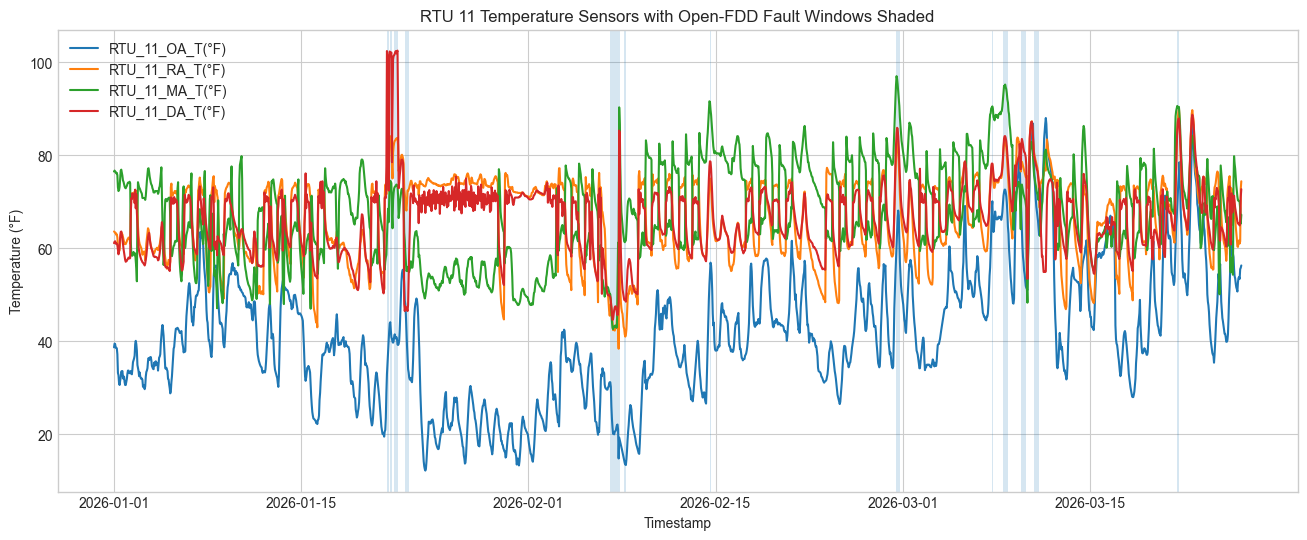

In [13]:
plot_series_with_fault_shading(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    series_cols=TEMP_SENSOR_COLS,
    fault_flag_col=FAULT_SHADE_FLAG,
    title="RTU 11 Temperature Sensors with Open-FDD Fault Windows Shaded",
    ylabel="Temperature (°F)",
    figsize=FIGSIZE_WIDE,
    shade_alpha=FAULT_SHADE_ALPHA,
)


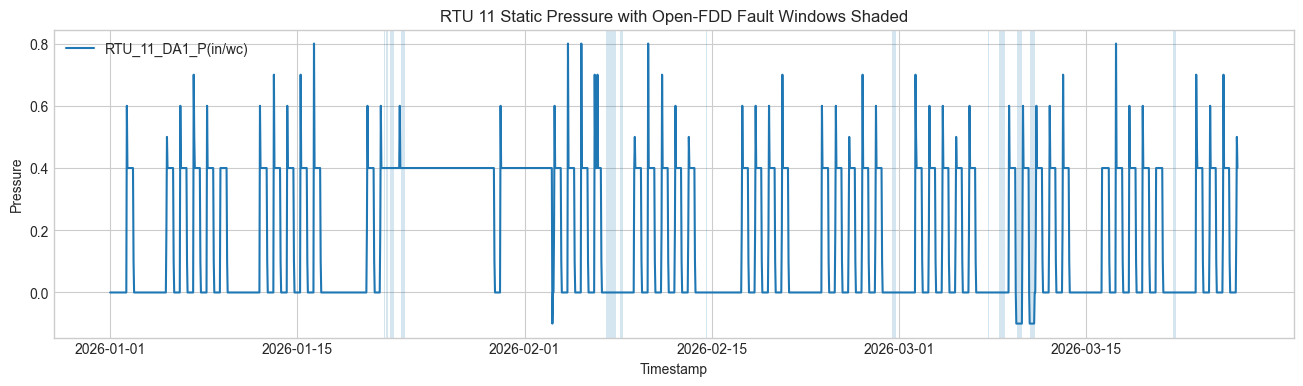

In [14]:
plot_series_with_fault_shading(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    series_cols=PRESSURE_SENSOR_COLS,
    fault_flag_col=FAULT_SHADE_FLAG,
    title="RTU 11 Static Pressure with Open-FDD Fault Windows Shaded",
    ylabel="Pressure",
    figsize=FIGSIZE_MED,
    shade_alpha=FAULT_SHADE_ALPHA,
)


## Zoom in on individual sensors

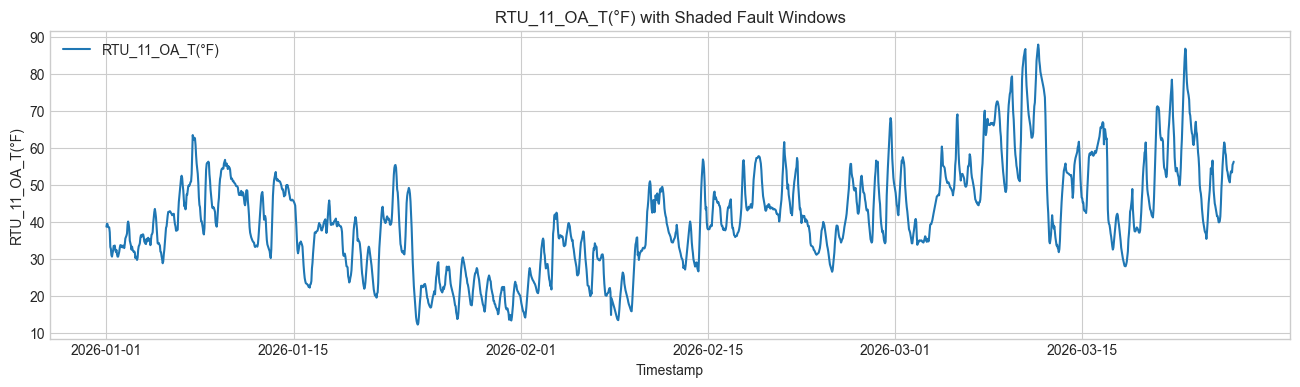

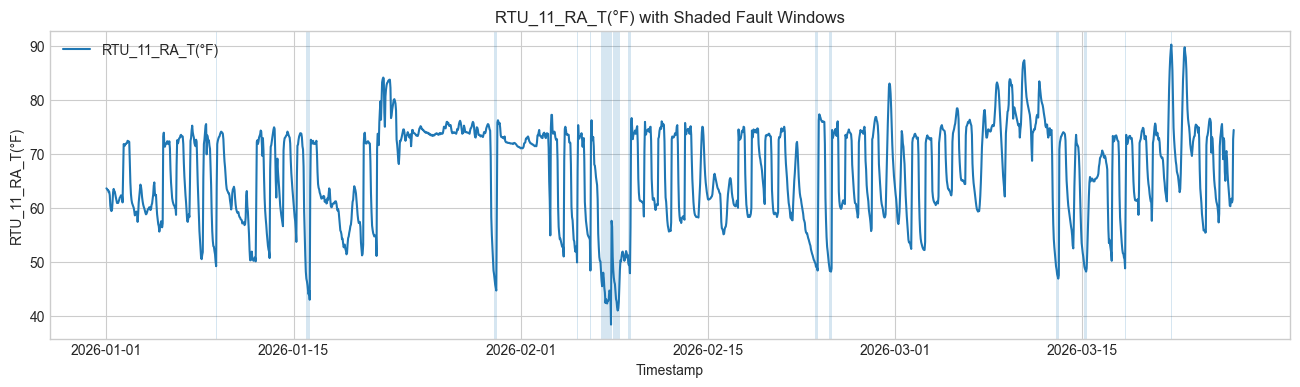

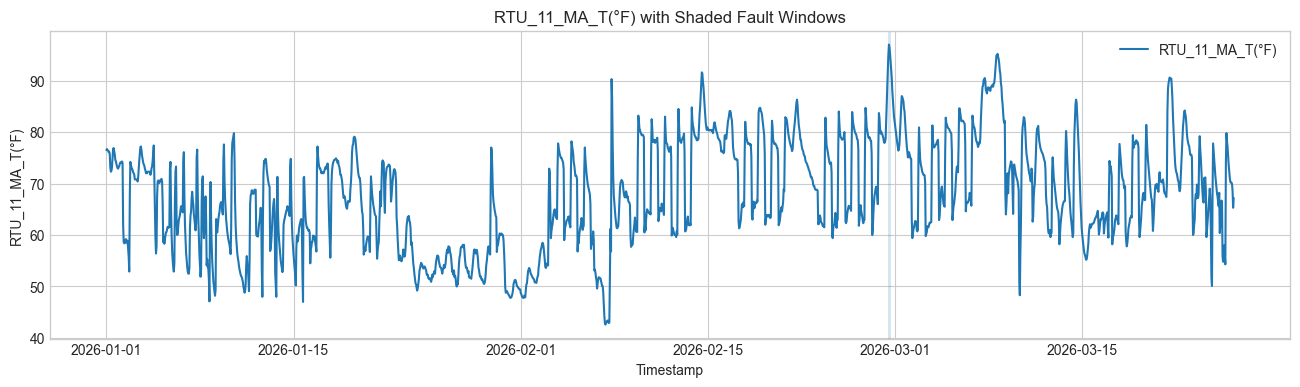

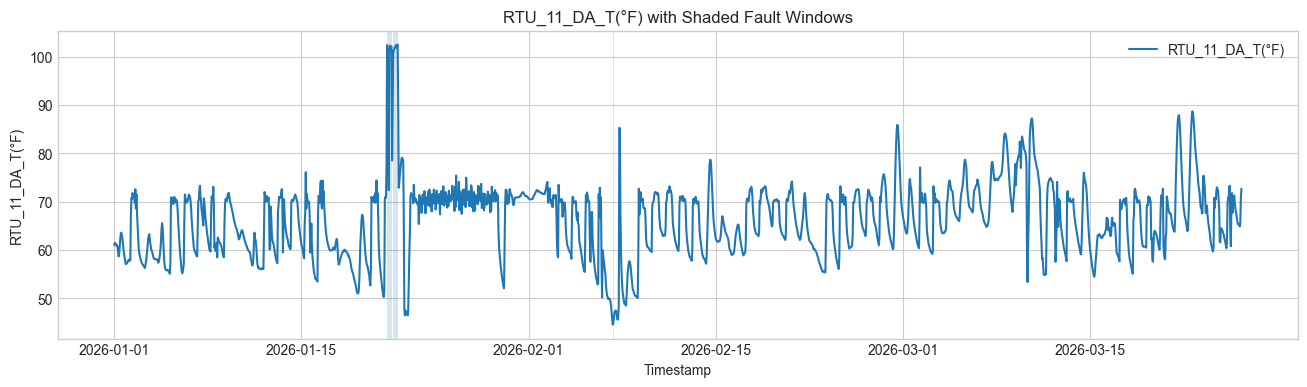

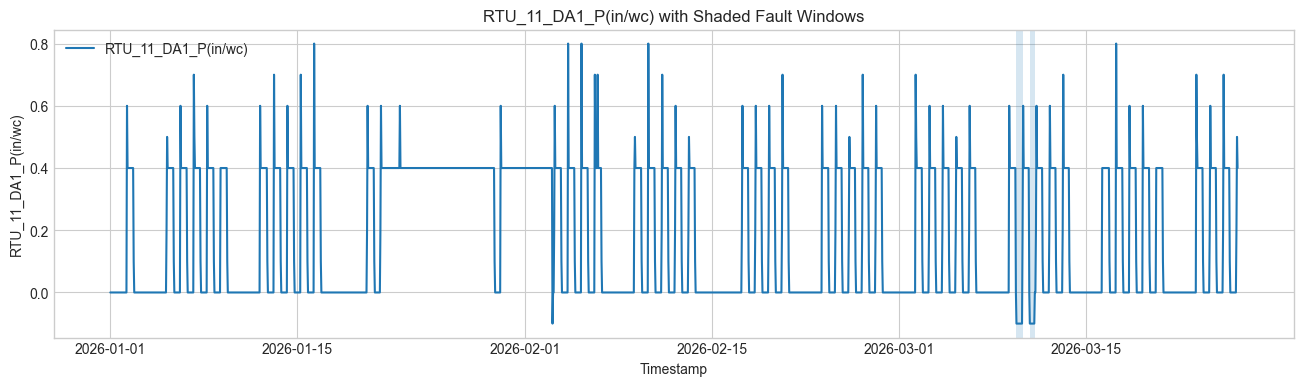

In [15]:
for sensor in DIRECT_BOUNDS_MAP.keys():
    plot_sensor_with_bad_windows(
        df_result=df_result,
        timestamp_col=TIMESTAMP_COL,
        sensor_col=sensor,
        fault_suffix="_bounds_fault",
        figsize=FIGSIZE_MED,
        shade_alpha=FAULT_SHADE_ALPHA,
    )


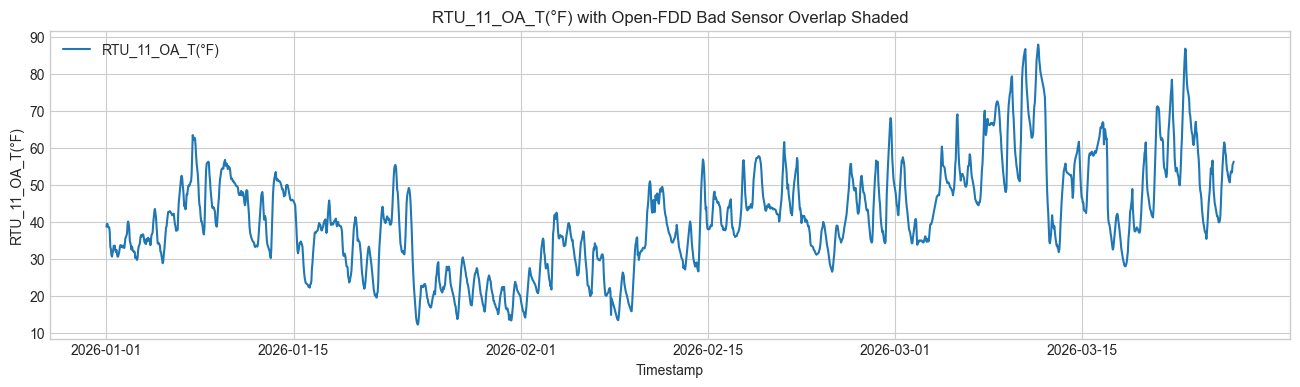

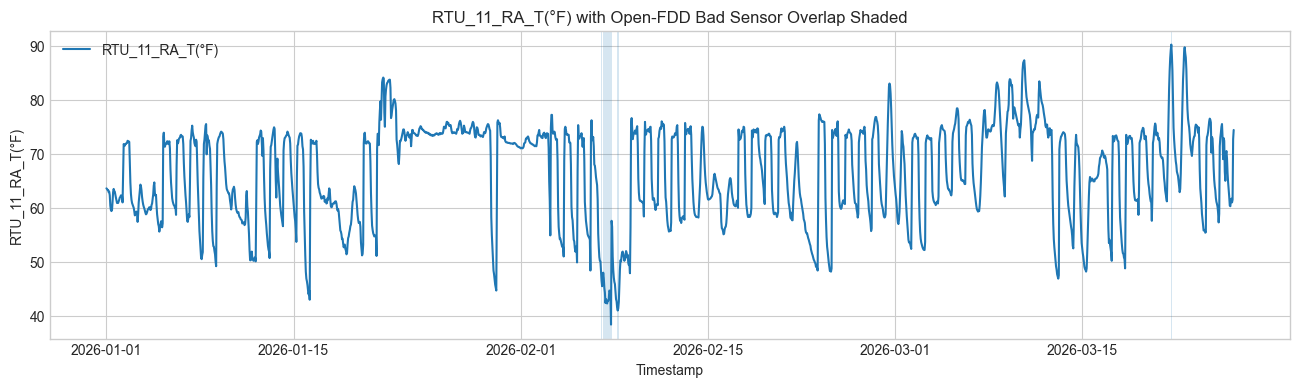

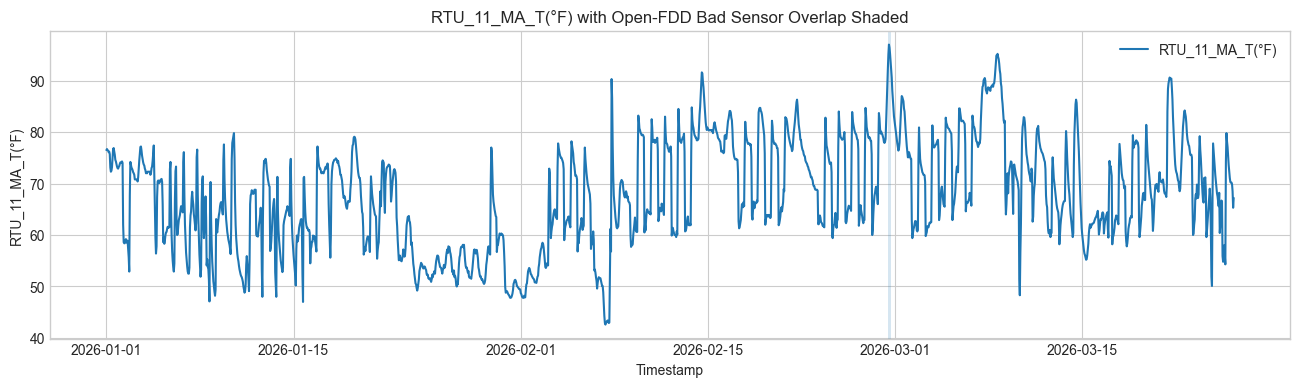

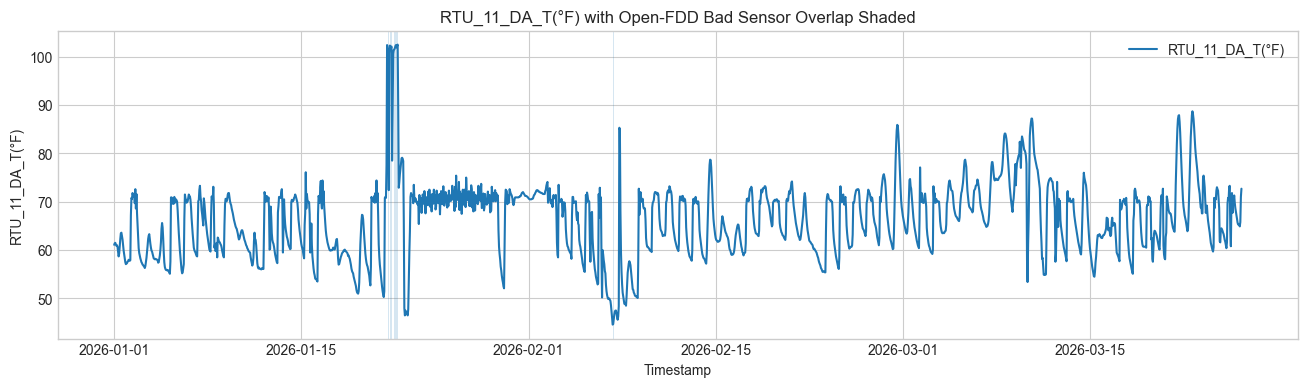

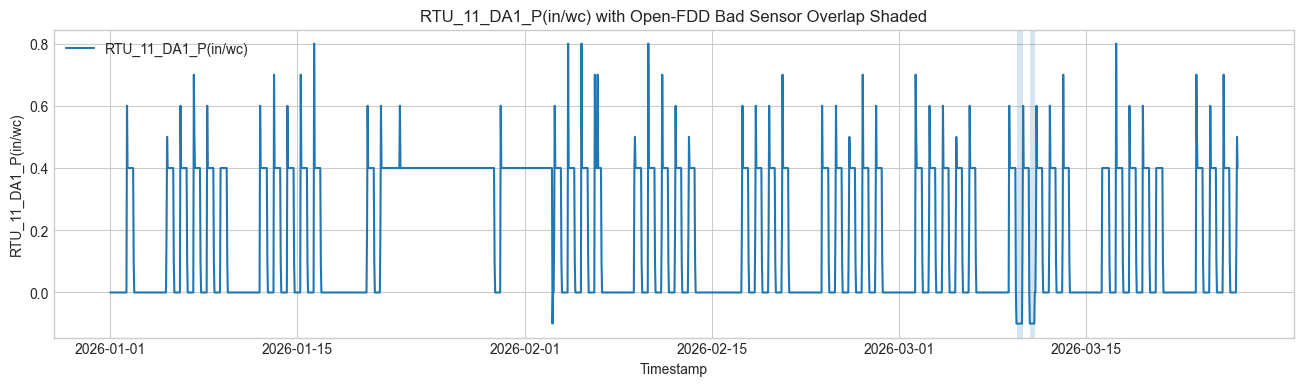

In [16]:
for sensor in DIRECT_BOUNDS_MAP.keys():
    plot_sensor_with_openfdd_overlap(
        df_result=df_result,
        timestamp_col=TIMESTAMP_COL,
        sensor_col=sensor,
        fault_flag_col=FAULT_SHADE_FLAG,
        fault_suffix="_bounds_fault",
        figsize=FIGSIZE_MED,
        shade_alpha=FAULT_SHADE_ALPHA,
    )


In [17]:
direct_bad_mask = df_result[[f"{c}_bounds_fault" for c in DIRECT_BOUNDS_MAP.keys()]].any(axis=1)

df_result.loc[
    direct_bad_mask,
    [TIMESTAMP_COL] + list(DIRECT_BOUNDS_MAP.keys()) + [f"{c}_bounds_fault" for c in DIRECT_BOUNDS_MAP.keys()]
].head(50)


,timestamp,RTU_11_OA_T(°F),RTU_11_RA_T(°F),RTU_11_MA_T(°F),RTU_11_DA_T(°F),RTU_11_DA1_P(in/wc),RTU_11_OA_T(°F)_bounds_fault,RTU_11_RA_T(°F)_bounds_fault,RTU_11_MA_T(°F)_bounds_fault,RTU_11_DA_T(°F)_bounds_fault,RTU_11_DA1_P(in/wc)_bounds_fault
197,2026-01-09 05:00:00,39.1,49.2,63.1,58.5,-0.0,0,1,0,0,0
358,2026-01-15 22:00:00,23.4,48.2,62.7,56.2,-0.0,0,1,0,0,0
359,2026-01-15 23:00:00,23.3,46.9,61.9,55.3,-0.0,0,1,0,0,0
360,2026-01-16 00:00:00,23.2,46.4,61.4,54.8,-0.0,0,1,0,0,0
361,2026-01-16 01:00:00,23.0,45.7,61.4,54.1,-0.0,0,1,0,0,0
362,2026-01-16 02:00:00,22.9,44.7,61.0,54.0,-0.0,0,1,0,0,0
363,2026-01-16 03:00:00,22.4,44.0,60.8,54.0,-0.0,0,1,0,0,0
364,2026-01-16 04:00:00,22.6,44.7,61.0,53.7,-0.0,0,1,0,0,0
365,2026-01-16 05:00:00,22.2,43.0,60.4,53.5,-0.0,0,1,0,0,0
490,2026-01-21 10:00:00,32.9,75.8,62.5,102.4,0.4,0,0,0,1,0


## Fan runtime KPIs

In [18]:
df_result, fan_logic_used, total_fan_run_hours = compute_fan_runtime(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    fan_status_col=FAN_STATUS_COL,
    fan_output_col=FAN_OUTPUT_COL,
    fan_output_threshold=FAN_OUTPUT_THRESHOLD,
)

print("Fan logic used:", fan_logic_used)
print(f"Total fan run hours: {total_fan_run_hours:.2f}")


Fan logic used: RTU_11_SF_S parsed as numeric/text status, forward-filled
Total fan run hours: 929.00


c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\openfdd_notebook_helpers_v2.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_result["fan_on"] = status_bool.ffill().fillna(False).astype(bool)


In [19]:
weekly_fan_hours = weekly_fan_runtime(df_result, TIMESTAMP_COL)
weekly_fan_hours.head()


timestamp
2026-01-04     12.0
2026-01-11     63.0
2026-01-18     65.0
2026-01-25    128.0
2026-02-01    157.0
Freq: W-SUN, Name: fan_run_hours, dtype: float64

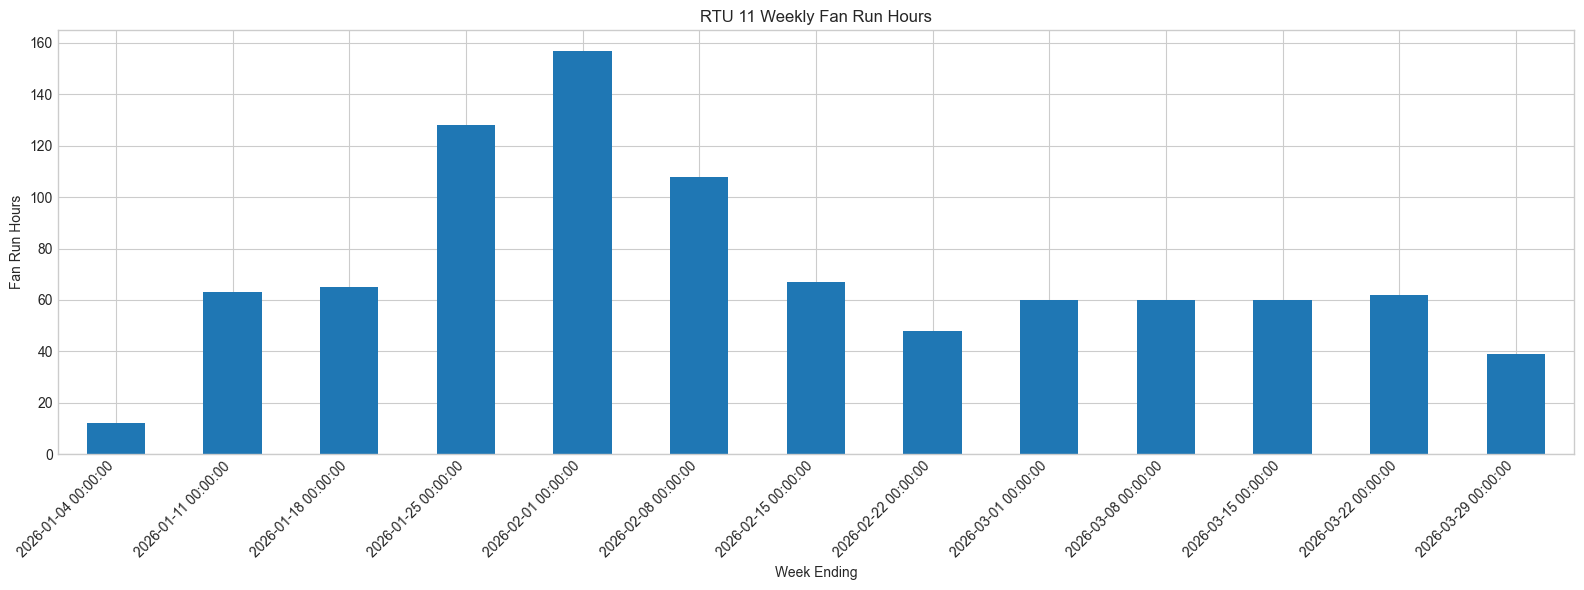

In [20]:
plot_weekly_fan_runtime(
    weekly_fan_hours,
    title="RTU 11 Weekly Fan Run Hours",
    figsize=FIGSIZE_WIDE,
)


for sensor in DIRECT_BOUNDS_MAP.keys():
    plot_sensor_fault_pies(
        df_result=df_result,
        sensor_col=sensor,
        rule_name="Bounds",
        fault_suffix="_bounds_fault",
        bounds_map=DIRECT_BOUNDS_MAP,
    )


## Aggregate pie charts from Open-FDD flags

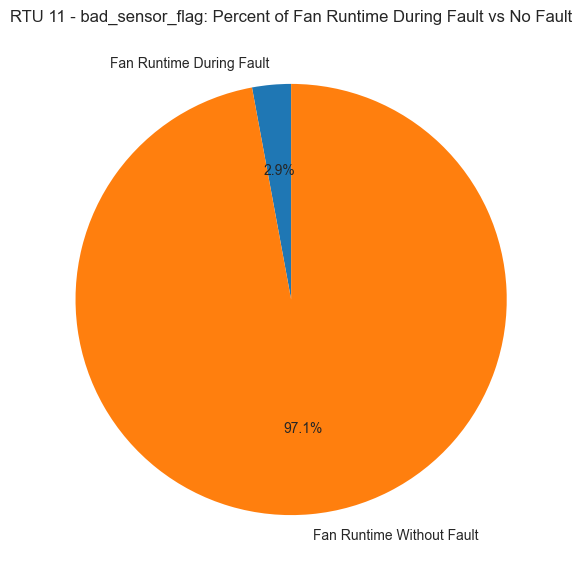

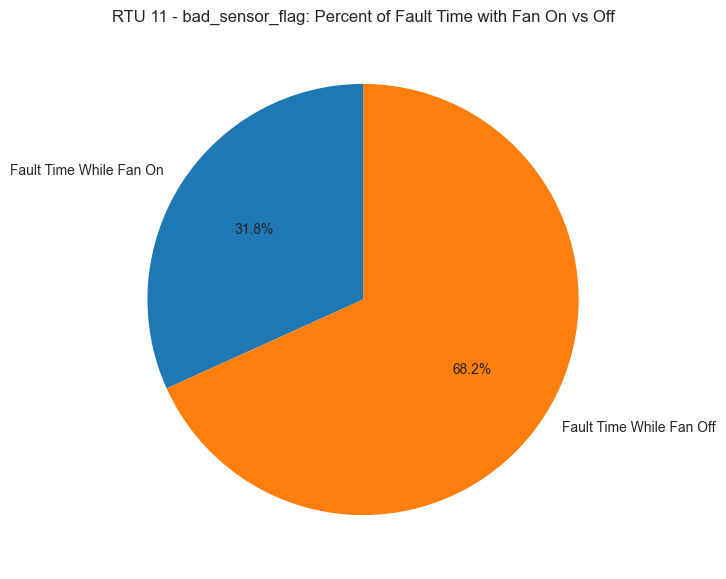

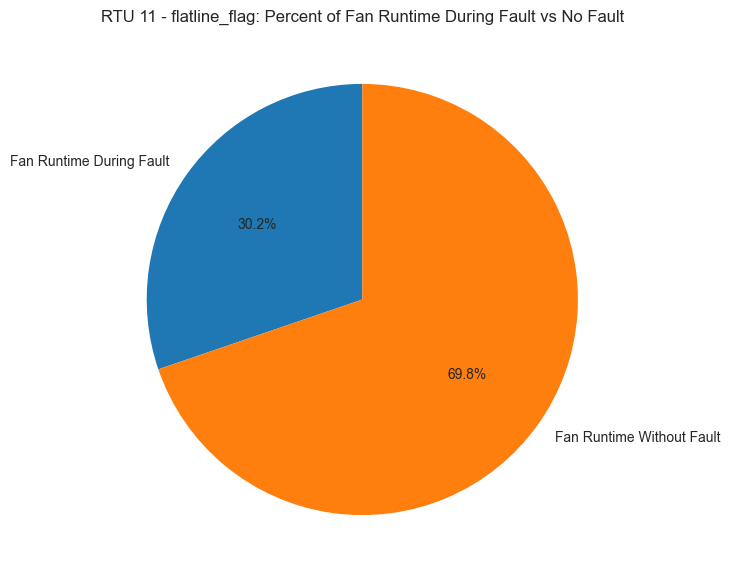

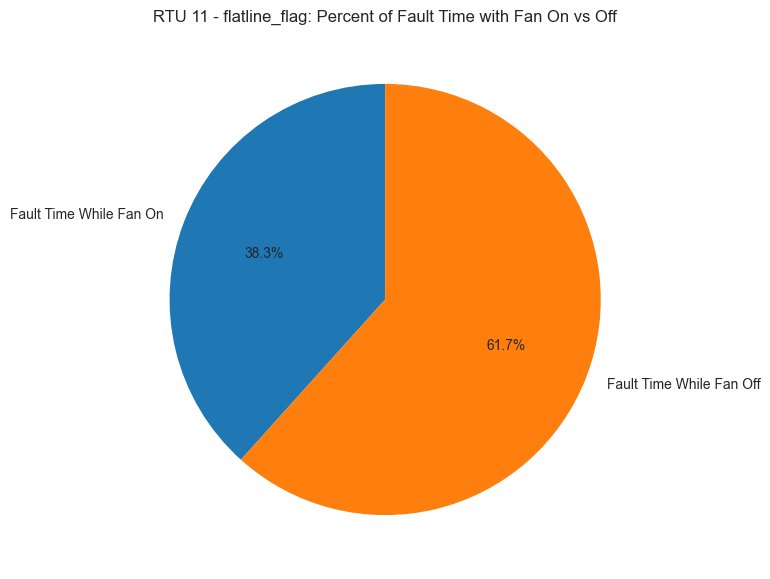

In [21]:
plot_fault_pies(df_result, FAULT_SHADE_FLAG, title_prefix="RTU 11 - bad_sensor_flag")
plot_fault_pies(df_result, FLATLINE_FLAG, title_prefix="RTU 11 - flatline_flag")
